In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')

In [40]:
df = pd.read_csv('datathon_2026_round1/dataset/interim/csv_exports/customers_base.csv')

In [6]:
df.shape

(121930, 7)

In [8]:
df.head(20)

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,hai phong,2021-12-30,female,35-44,social_media
1,2,15201,hai phong,2013-12-27,female,45-54,email_campaign
2,3,15201,hai phong,2018-07-24,female,18-24,organic_search
3,4,15201,hai phong,2017-11-29,male,35-44,referral
4,5,15201,hai phong,2022-09-23,male,55+,organic_search
5,6,15202,phu ly,2022-04-14,female,25-34,organic_search
6,8,15202,phu ly,2015-09-11,male,45-54,social_media
7,9,15202,phu ly,2020-02-14,male,35-44,email_campaign
8,10,15202,phu ly,2014-03-03,male,25-34,organic_search
9,11,15203,viet tri,2017-11-07,male,35-44,organic_search


In [10]:
df.columns

Index(['customer_id', 'zip', 'city', 'signup_date', 'gender', 'age_group',
       'acquisition_channel'],
      dtype='object')

In [11]:
df.dtypes

customer_id             int64
zip                     int64
city                   object
signup_date            object
gender                 object
age_group              object
acquisition_channel    object
dtype: object

In [41]:
df.sort_values(by='signup_date')

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
69324,89559,57037,da nang,2012-01-17,male,35-44,direct
10153,13075,12037,ninh binh,2012-01-20,female,35-44,paid_search
7630,9810,14534,ha long,2012-02-02,male,25-34,paid_search
106902,138107,92029,bac lieu,2012-02-05,male,55+,paid_search
32889,42450,8203,son tay,2012-02-07,female,25-34,organic_search
...,...,...,...,...,...,...,...
59940,77429,38638,phan thiet,2022-12-31,male,35-44,email_campaign
2279,2936,15697,hai phong,2022-12-31,male,55+,organic_search
27489,35426,46385,lao cai,2022-12-31,female,25-34,organic_search
27979,36049,46977,bac ninh,2022-12-31,female,35-44,organic_search


In [42]:
df['signup_date'].value_counts()

signup_date
2022-06-02    78
2022-11-13    77
2022-11-15    76
2022-07-18    75
2021-10-31    75
              ..
2012-02-20     1
2012-03-14     1
2012-04-20     1
2012-04-11     1
2012-05-09     1
Name: count, Length: 3941, dtype: int64

In [44]:
df.query('signup_date == "2022-06-02"')

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
3885,4981,16720,hanoi,2022-06-02,female,45-54,referral
5766,7406,18066,bac ninh,2022-06-02,male,25-34,referral
5836,7501,18202,thai nguyen,2022-06-02,female,35-44,paid_search
5999,7707,18334,lao cai,2022-06-02,male,18-24,paid_search
6492,8343,18625,phu ly,2022-06-02,female,45-54,paid_search
...,...,...,...,...,...,...,...
110154,142297,90011,pleiku,2022-06-02,male,25-34,organic_search
113265,146347,81144,ben tre,2022-06-02,female,25-34,paid_search
114068,147397,97298,rach gia,2022-06-02,female,35-44,social_media
118440,153031,98902,bac lieu,2022-06-02,female,45-54,paid_search


In [45]:
df['acquisition_channel'].value_counts()

acquisition_channel
organic_search    36450
social_media      24448
paid_search       24285
email_campaign    14674
referral          12270
direct             9803
Name: count, dtype: int64

Text(0, 0.5, 'Count')

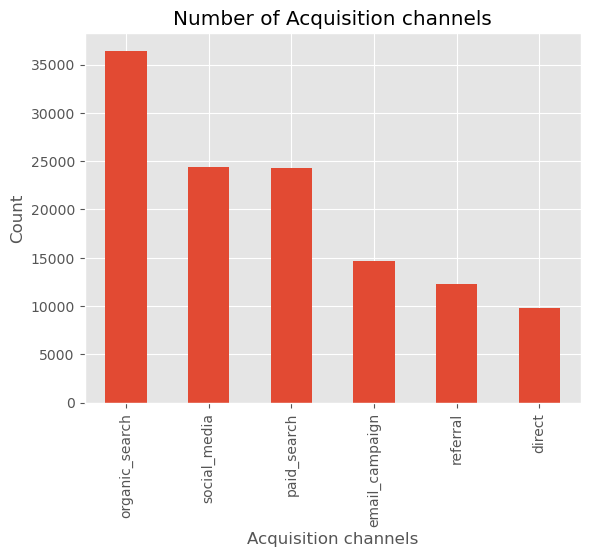

In [47]:
ax = df['acquisition_channel'].value_counts() \
    .plot(kind='bar', title='Number of Acquisition channels')
ax.set_xlabel('Acquisition channels')
ax.set_ylabel('Count')

In [13]:
df.describe()

,customer_id,zip
count,121930.000000,121930.000000
mean,78736.898663,50990.165595
std,45492.202886,26871.914605
min,1.000000,1001.000000
25%,39343.500000,28689.250000
50%,78784.500000,49835.000000
75%,118156.750000,73488.000000
max,157563.000000,99950.000000


In [48]:
df['customer_id'].duplicated().sum()

np.int64(0)

In [49]:
df['customer_id'].isnull().sum()

np.int64(0)

In [50]:
df['zip'].astype(str).str.len().value_counts()

zip
5    116100
4      5830
Name: count, dtype: int64

In [51]:
df['zip'] = df['zip'].astype(str).str.zfill(5)

In [15]:
df['signup_date'] = pd.to_datetime(df['signup_date'])

In [52]:
df['zip'].astype(str).str.len().value_counts()

zip
5    121930
Name: count, dtype: int64

In [54]:
df['zip'].value_counts()

zip
90250    6
92592    6
93065    6
21031    5
21001    5
        ..
06112    1
71111    1
89158    1
93412    1
32541    1
Name: count, Length: 31491, dtype: int64

In [19]:
df.isna().sum() # Check null value

customer_id            0
zip                    0
city                   0
signup_date            0
gender                 0
age_group              0
acquisition_channel    0
dtype: int64

In [21]:
df.duplicated() # Check duplicate value

0         False
1         False
2         False
3         False
4         False
          ...  
121925    False
121926    False
121927    False
121928    False
121929    False
Length: 121930, dtype: bool

In [24]:
df.loc[df.duplicated(subset=['customer_id'])]
df.loc[df.duplicated(subset=['zip'])]
df.loc[df.duplicated(subset=['city'])]
df.loc[df.duplicated(subset=['signup_date'])]
df.loc[df.duplicated(subset=['gender'])]
df.loc[df.duplicated(subset=['age_group'])]
df.loc[df.duplicated(subset=['acquisition_channel'])]

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
4,5,15201,hai phong,2022-09-23,male,55+,organic_search
5,6,15202,phu ly,2022-04-14,female,25-34,organic_search
6,8,15202,phu ly,2015-09-11,male,45-54,social_media
7,9,15202,phu ly,2020-02-14,male,35-44,email_campaign
8,10,15202,phu ly,2014-03-03,male,25-34,organic_search
...,...,...,...,...,...,...,...
121925,157556,59936,vung tau,2016-03-03,female,18-24,direct
121926,157557,59936,vung tau,2021-05-11,female,45-54,social_media
121927,157558,59936,vung tau,2017-02-27,female,25-34,referral
121928,157561,59937,buon ma thuot,2018-10-15,non-binary,45-54,paid_search


In [25]:
df = pd.read_csv('datathon_2026_round1/dataset/interim/csv_exports/sales_base.csv')

In [27]:
df.dtypes

date        object
revenue    float64
cogs       float64
dtype: object

In [28]:
df['date'] = pd.to_datetime(df['date'])

In [29]:
df.dtypes

date       datetime64[ns]
revenue           float64
cogs              float64
dtype: object

In [30]:
df

,date,revenue,cogs
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79
...,...,...,...
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15


In [32]:
df.describe()

,date,revenue,cogs
count,3833,3.833000e+03,3.833000e+03
mean,2017-10-02 00:00:00,4.286584e+06,3.695134e+06
min,2012-07-04 00:00:00,2.798139e+05,2.365763e+05
25%,2015-02-17 00:00:00,2.471089e+06,2.150580e+06
50%,2017-10-02 00:00:00,3.647304e+06,3.161113e+06
75%,2020-05-17 00:00:00,5.350877e+06,4.637294e+06
max,2022-12-31 00:00:00,2.090527e+07,1.653586e+07
std,NaN,2.624840e+06,2.219789e+06


In [33]:
df = pd.read_csv('datathon_2026_round1/dataset/interim/csv_exports/orders_base.csv')

In [37]:
df.dtypes

order_id                   int64
order_date        datetime64[ns]
customer_id                int64
zip                        int64
order_status              object
payment_method            object
device_type               object
order_source              object
dtype: object

In [36]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [38]:
df

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign
...,...,...,...,...,...,...,...,...
646940,834372,2022-12-31,19490,33907,delivered,credit_card,mobile,email_campaign
646941,834377,2022-12-31,73046,37091,delivered,credit_card,mobile,referral
646942,834387,2022-12-31,107723,80516,delivered,credit_card,mobile,email_campaign
646943,834392,2022-12-31,139431,93510,delivered,paypal,desktop,direct
